# **LAB 3: Neural Networks: Feedforward Networks and the Training Process**

In [63]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


## **Section 1 - Inside a Neural Network: From One Neuron to Gradient Descent**

## Part 1.1 - A single neuron is just a line

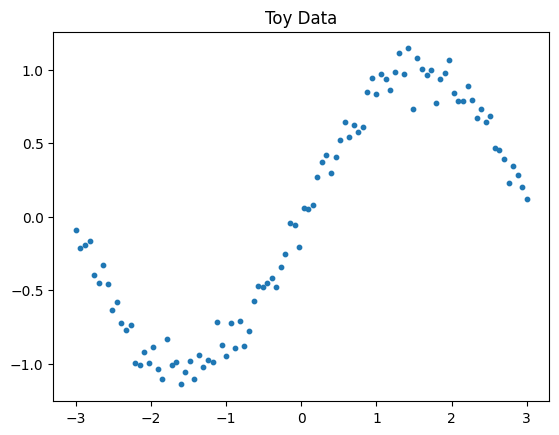

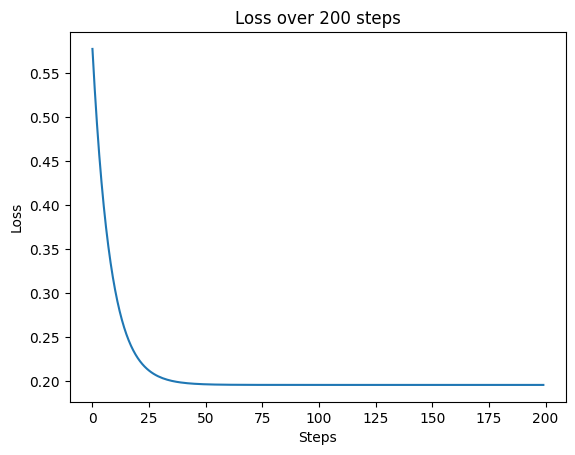

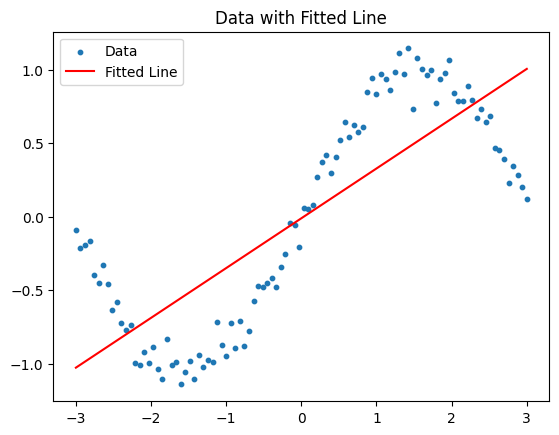

In [64]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size = x.shape)

plt.scatter(x, y, s = 10)
plt.title("Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
lr = 0.01
losses = []

for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.plot(losses)
plt.title("Loss over 200 steps")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

plt.scatter(x, y, s = 10, label = "Data")
plt.plot(x, y_hat, color = "red", label = "Fitted Line")
plt.title("Data with Fitted Line")
plt.legend()
plt.show()


1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?



2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

This is underfitting. A single neuron can learn in a straight liine only, while the sine wave is curved in nature so no matter how long you train, nothing changes because the model cannot adapt.

## Part 1.2 - Hidden layers and activations: why depth helps

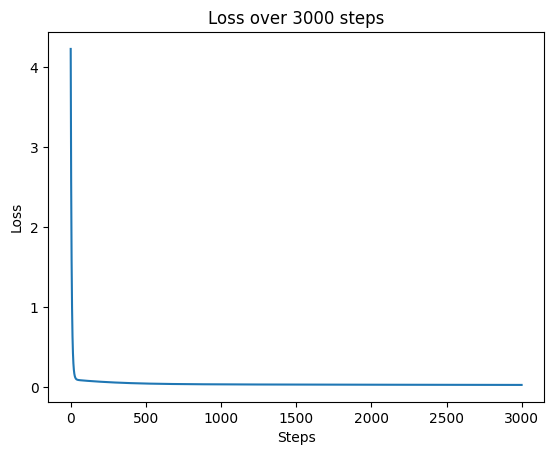

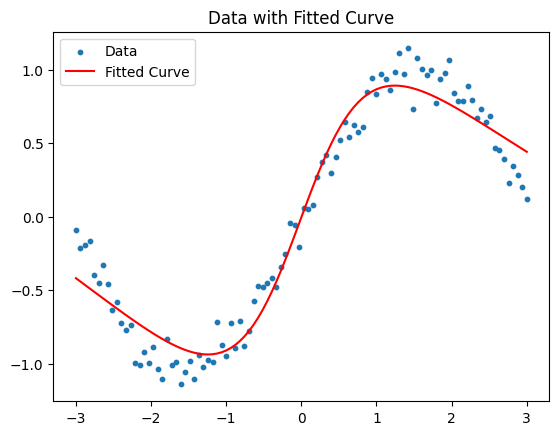

In [65]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

lr = 0.01
losses = []

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
for step in range(3000):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis = 0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.plot(losses)
plt.title("Loss over 3000 steps")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

plt.scatter(x, y, s = 10, label = "Data")
plt.plot(x, y_hat, color = "red", label = "Fitted Curve")
plt.title("Data with Fitted Curve")
plt.legend()
plt.show()


1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.

This is because multiple layers combined is still a linear equation. Without an activation function, the network cannot create curves so it still acts like how one neuron would.

2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.) 

The 8 neurons were used to learn different patterns from the input data. They combined these patterns to create a curved output that could fit the sine wave.

3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?

Back propagation is the process of checking how much each weight contributed to the difference between the output and the loss and adjusting the weights to reduce the loss.

## Part 1.3 - The learning rate: too cold, too hot, just right

/Users/dbbarimah/Desktop/Introduction to Artificial Intelligence/ai_env/lib/python3.9/site-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/h_/034s64bx5w50f7602cjs11ww0000gn/T/ipykernel_60424/4124904670.py:16: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/var/folders/h_/034s64bx5w50f7602cjs11ww0000gn/T/ipykernel_60424/4124904670.py:21: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/var/folders/h_/034s64bx5w50f7602cjs11ww0000gn/T/ipykernel_60424/4124904670.py:22: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/Users/dbbarimah/Desktop/Introduction to Artificial Intelligence/ai_env/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


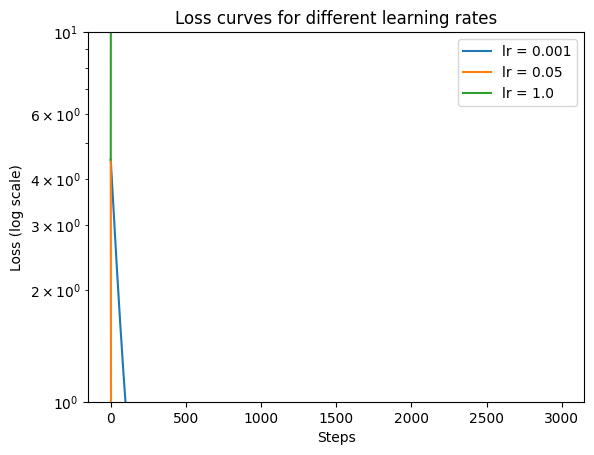

In [66]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps = 3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(3000):
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)

        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis = 0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis = 0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)

    return losses
    
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_slow = train_toy(lr = 0.001)
losses_good = train_toy(lr = 0.05)
losses_fast = train_toy(lr = 1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure()
plt.plot(losses_slow, label = "lr = 0.001")
plt.plot(losses_good, label = "lr = 0.05")
plt.plot(losses_fast, label = "lr = 1.0")
plt.yscale("log")
plt.title("Loss curves for different learning rates")
plt.xlabel("Steps")
plt.ylabel("Loss (log scale)")
plt.legend()
plt.show()


Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

A small learning rate learns slowly and steadily, a medium learning rate reduces the loss faster and a large learning rate may miss the best values and cause the loss to inrease instead of reducing.

## **SECTION 2: A real Feedforward Network in PyTorch**

## Part 2.1 - Preprocess and split (recycled from Lab 2)

In [67]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity =pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
obesity[binary_cols] = obesity[binary_cols].replace({'yes': 1, 'no': 0})
obesity = pd.get_dummies(obesity, columns = ['Gender', 'MTRANS'], drop_first = True)

freq_order = ['no', 'Sometimes', 'Frequently', 'Always']
ord_encoder = OrdinalEncoder(categories = [freq_order, freq_order])
obesity[['CAEC', 'CALC']] = ord_encoder.fit_transform(obesity[['CAEC', 'CALC']])

obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop(columns = ['NObeyesdad'])
y = obesity['NObeyesdad']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = RANDOM_STATE)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_t = torch.tensor(X_train, dtype = torch.float32)
X_val_t = torch.tensor(X_val, dtype = torch.float32)
X_test_t = torch.tensor(X_test, dtype = torch.float32)
y_train_t = torch.tensor(y_train.values, dtype = torch.long)
y_val_t = torch.tensor(y_val.values, dtype = torch.long)
y_test_t = torch.tensor(y_test.values, dtype = torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size = 32, shuffle = False)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size = 32, shuffle = False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size = 32, shuffle = False)

print("Train: ", X_train_t.shape, "Val: ", X_val_t.shape, "Test: ", X_test_t.shape)

Train:  torch.Size([1477, 20]) Val:  torch.Size([317, 20]) Test:  torch.Size([317, 20])


/var/folders/h_/034s64bx5w50f7602cjs11ww0000gn/T/ipykernel_60424/3970957899.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  obesity[binary_cols] = obesity[binary_cols].replace({'yes': 1, 'no': 0})


1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

CrossEntropyLoss needs integer class labels so that it can directly compare the prediction with the correct class.

2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks use gradients to update weights and using very different feature scales make the learning process unstable. Rando forest uses decision rules whihc are not affected as much by the feature sizes.

3. What does shuffle=True on the training DataLoader do, and why does it help?

It changes the order of the training samples for each epoch. This helps to prevent the model from learning patterns based only on the order of the data and reduce overfitting.

## Part 2.2 Design the network

In [68]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes = (64, 32), n_classes = 7, dropout = 0.0):
        super().__init__()

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])

        if len(hidden_sizes) > 1:
            self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
            self.output = nn.Linear(hidden_sizes[1], n_classes)
        else:
            self.fc2 = None
            self.output = nn.Linear(hidden_sizes[0], n_classes)

        if len(hidden_sizes) > 2:
            self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
            self.output = nn.Linear(hidden_sizes[2], n_classes)
        else:
            self.fc3 = None

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        if self.fc2 is not None:
            x = self.dropout(self.relu(self.fc2(x)))
        if self.fc3 is not None:
            x = self.dropout(self.relu(self.fc3(x)))
        x = self.output(x)
        return x

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_t.shape[1]
model = FeedForwardNet(input_dim = input_dim).to(DEVICE)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_parameters}")
print(f"First layer by hand: {input_dim * 64 + 64}")

Total trainable parameters: 3655
First layer by hand: 1344


1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.



2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage. 

ReLU is used here instead of tanh because it is faster to compute and helps deep networks train more effectively since the vanishing gradient problem is reduced.

3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

Without the ReLUs, all the layers would basically become linear operations so the network would be the same as a linear model.

## Part 2.3 - The training loop

Epoch 1/50, Training Loss: 1.6705, Validation Loss: 1.6850, Training Accuracy: 0.4624, Validation Accuracy: 0.4385
Epoch 2/50, Training Loss: 1.1685, Validation Loss: 1.1921, Training Accuracy: 0.6378, Validation Accuracy: 0.6593
Epoch 3/50, Training Loss: 0.8477, Validation Loss: 0.8837, Training Accuracy: 0.7326, Validation Accuracy: 0.7066
Epoch 4/50, Training Loss: 0.6588, Validation Loss: 0.7179, Training Accuracy: 0.8050, Validation Accuracy: 0.7603
Epoch 5/50, Training Loss: 0.5274, Validation Loss: 0.6054, Training Accuracy: 0.8436, Validation Accuracy: 0.8044
Epoch 6/50, Training Loss: 0.4336, Validation Loss: 0.5232, Training Accuracy: 0.8693, Validation Accuracy: 0.8297
Epoch 7/50, Training Loss: 0.3647, Validation Loss: 0.4619, Training Accuracy: 0.8991, Validation Accuracy: 0.8738
Epoch 8/50, Training Loss: 0.3122, Validation Loss: 0.4151, Training Accuracy: 0.9160, Validation Accuracy: 0.8833
Epoch 9/50, Training Loss: 0.2698, Validation Loss: 0.3783, Training Accuracy: 0

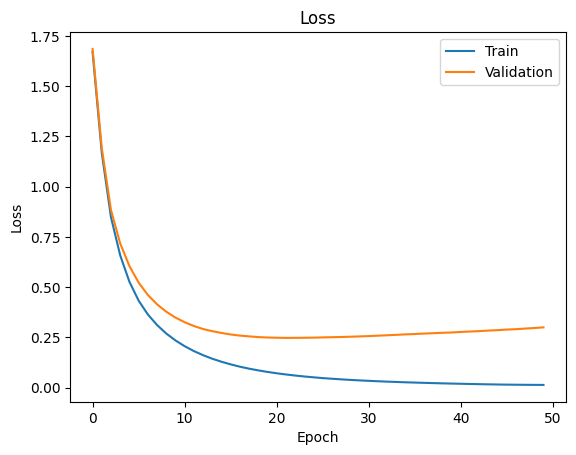

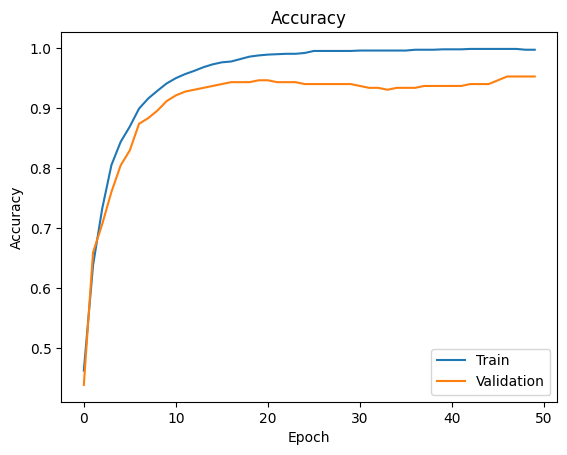

In [69]:
from sklearn.metrics import accuracy_score

# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
epochs = 50
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()
     
    model.eval()
    with torch.no_grad():
        train_logits = model(X_train_t.to(DEVICE))
        train_loss = criterion(train_logits, y_train_t.to(DEVICE)).item()
        train_preds = train_logits.argmax(dim = 1).cpu().numpy()
        train_acc = accuracy_score(y_train_t.numpy(), train_preds)

        val_logits = model(X_val_t.to(DEVICE))
        val_loss = criterion(val_logits, y_val_t.to(DEVICE)).item()
        val_preds = val_logits.argmax(dim = 1).cpu().numpy()
        val_acc = accuracy_score(y_val_t.numpy(), val_preds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")


# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.plot(train_losses, label = "Train")
plt.plot(val_losses, label = "Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(train_accs, label = "Train")
plt.plot(val_accs, label = "Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?

logits = model(x) becomes the forward pass
loss.backward() calculates the gradients
optimizer.step() updates the weights

2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.

The model is slightly overfitting. With an accuracy score of almost 95%, and the validation loss 

3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?

Pytorch adds new gradients to the old ones. zero_grad() clears the previous gradients so that each update uses only the current batch.


## Part 2.4 Experiments: how training choices change the outcome

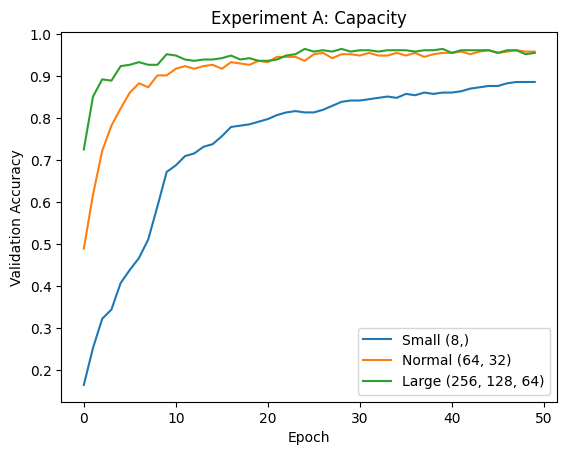

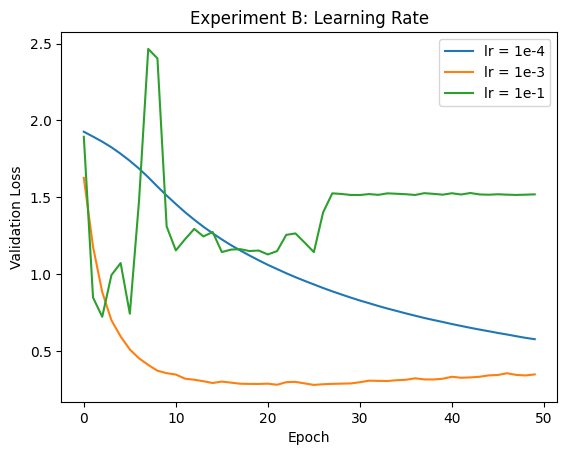

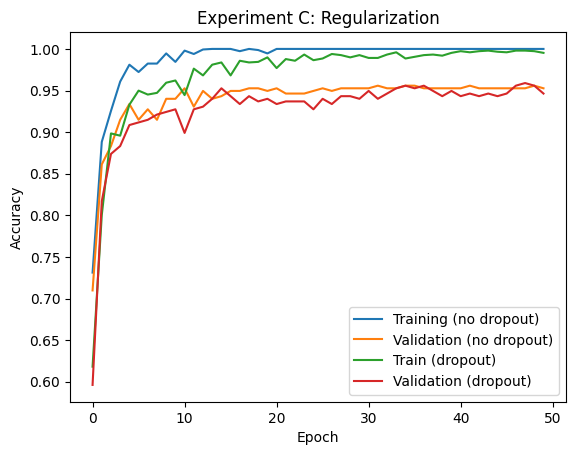

In [70]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes = (64, 32), lr = 1e-3, batch_size = 32, epochs = 50, dropout = 0.0):
    model = FeedForwardNet(input_dim = input_dim, hidden_sizes = hidden_sizes, dropout = dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size = batch_size, shuffle = True)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
                train_logits = model(X_train_t.to(DEVICE))
                train_loss = criterion(train_logits, y_train_t.to(DEVICE)).item()
                train_acc = accuracy_score(y_train_t.numpy(), train_logits.argmax(dim = 1).cpu().numpy())
        
                val_logits = model(X_val_t.to(DEVICE))
                val_loss = criterion(val_logits, y_val_t.to(DEVICE)).item()
                val_acc = accuracy_score(y_val_t.numpy(), val_logits.argmax(dim = 1).cpu().numpy())
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return {"train_loss": train_losses, "val_loss": val_losses, "train_acc": train_accs, "val_acc": val_accs}

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
history_small = run_experiment(hidden_sizes = (8,))
history_normal = run_experiment(hidden_sizes = (64,32))
history_big = run_experiment(hidden_sizes = (256, 128, 64))

plt.plot(history_small["val_acc"], label = "Small (8,)")
plt.plot(history_normal["val_acc"], label = "Normal (64, 32)")
plt.plot(history_big["val_acc"], label = "Large (256, 128, 64)")
plt.title("Experiment A: Capacity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
history_slow = run_experiment(lr = 1e-4)
history_default = run_experiment(lr = 1e-3)
history_fast = run_experiment(lr = 1e-1)

plt.plot(history_slow["val_loss"], label = "lr = 1e-4")
plt.plot(history_default["val_loss"], label = "lr = 1e-3")
plt.plot(history_fast["val_loss"], label = "lr = 1e-1")
plt.title("Experiment B: Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
history_no_dropout = run_experiment(hidden_sizes = (256, 128, 64), dropout = 0.0)
history_dropout = run_experiment(hidden_sizes = (256, 128, 64), dropout = 0.3)

plt.plot(history_no_dropout["train_acc"], label = "Training (no dropout)")
plt.plot(history_no_dropout["val_acc"], label = "Validation (no dropout)")
plt.plot(history_dropout["train_acc"], label = "Train (dropout)")
plt.plot(history_dropout["val_acc"], label = "Validation (dropout)")
plt.title("Experiment C: Regularization")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?

The largest network did not always perform the best becasue increase learning but also cause overfitting. After a certain point, adding more layers 

2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?

3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.

## Part 2.5 Final Evaluation and showdown with Lab 2

Test Accuracy: 0.9117
Test Macro-F1: 0.9104

                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.95      0.96        41
      Normal_Weight       0.86      0.84      0.85        43
     Obesity_Type_I       0.89      0.96      0.93        53
    Obesity_Type_II       0.98      0.93      0.95        45
   Obesity_Type_III       0.98      0.98      0.98        48
 Overweight_Level_I       0.80      0.86      0.83        43
Overweight_Level_II       0.90      0.84      0.87        44

           accuracy                           0.91       317
          macro avg       0.91      0.91      0.91       317
       weighted avg       0.91      0.91      0.91       317



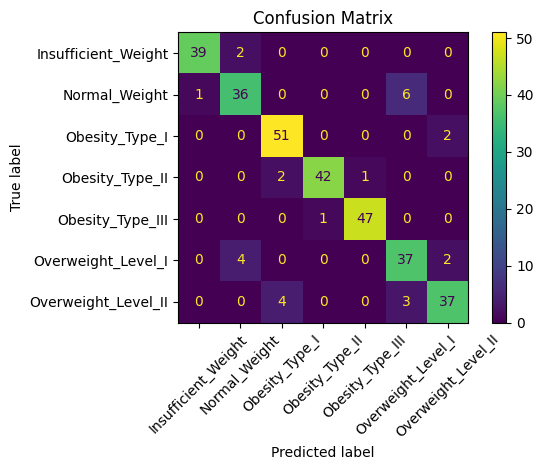

                      Model  Test Accuracy  Test Macro-F1 Parameters / Trees
Logistic Regression (Lab 2)       0.873800       0.869600   No hidden layers
     Neural Network (Lab 3)       0.911672       0.910437        3655 params


In [71]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# TODO: Load your best configuration's weights; model.eval().
best_model = FeedForwardNet(input_dim = input_dim, hidden_sizes = (64, 32)).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
with torch.no_grad():
    test_logits = best_model(X_test_t.to(DEVICE))
    test_preds = test_logits.argmax(dim = 1).cpu().numpy()

test_acc = accuracy_score(y_test_t.numpy(), test_preds)
test_f1 = f1_score(y_test_t.numpy(), test_preds, average = "macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print()
print(classification_report(y_test_t.numpy(), test_preds, target_names = label_encoder.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test_t.numpy(), test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = label_encoder.classes_)
disp.plot(xticks_rotation = 45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Lab 2)", "Neural Network (Lab 3)"],
    "Test Accuracy": [0.8738, test_acc],
    "Test Macro-F1": [0.8696, test_f1],
    "Parameters / Trees": ["No hidden layers", f"{sum(p.numel() for p in best_model.parameters())} params"]
})
print(comparison.to_string(index = False))

1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?

The network mainly confuses classes which have similar features

2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?

## **Section 3 - Reflection**

1. The black box, opened: Name the three most important things happening inside loss.backward() and optimizer.step(), in your own words.

The three most important things is that the model calculates the error, backpropagation fins how much each weight contributed to the error and the optimizer updates the weights to reduce the overall loss.

2. Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?

I would tune the learning rate because it controls how quickly and effectively the model learns.

3. Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?

The biggest gap came up when the larger models. The dropout reduced the overfitting by making the model generalise better.

4. Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?

MLPs treat every pixel independently and ignores the fact that the nearby pixels may relate to it. A better model like CNN  can understand the spatial environment and look at the relationships better.